In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

import matplotlib.pyplot as plt

In [3]:
path = "/home/silvy_linux/Desktop/Internship/Datasets/auto-mpg-engine-car.csv"
read_engine_mileage = pd.read_csv(path)
read_engine_mileage.head(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite


In [4]:
read_engine_mileage.isnull().sum() #check for missing values

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [5]:
duplicated = read_engine_mileage[read_engine_mileage.duplicated()]
print(duplicated)

Empty DataFrame
Columns: [mpg, cylinders, displacement, horsepower, weight, acceleration, model year, origin, car name]
Index: []


In [6]:
read_engine_mileage.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    str    
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    str    
dtypes: float64(3), int64(4), str(2)
memory usage: 28.1 KB


In [7]:
read_engine_mileage.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower          str
weight            int64
acceleration    float64
model year        int64
origin            int64
car name            str
dtype: object

In [8]:
read_engine_mileage['horsepower'].unique()  #we noticed ? that is junk

<StringArray>
['130', '165', '150', '140', '198', '220', '215', '225', '190', '170', '160',
  '95',  '97',  '85',  '88',  '46',  '87',  '90', '113', '200', '210', '193',
   '?', '100', '105', '175', '153', '180', '110',  '72',  '86',  '70',  '76',
  '65',  '69',  '60',  '80',  '54', '208', '155', '112',  '92', '145', '137',
 '158', '167',  '94', '107', '230',  '49',  '75',  '91', '122',  '67',  '83',
  '78',  '52',  '61',  '93', '148', '129',  '96',  '71',  '98', '115',  '53',
  '81',  '79', '120', '152', '102', '108',  '68',  '58', '149',  '89',  '63',
  '48',  '66', '139', '103', '125', '133', '138', '135', '142',  '77',  '62',
 '132',  '84',  '64',  '74', '116',  '82']
Length: 94, dtype: str

In [9]:
vc = read_engine_mileage['horsepower'].value_counts() #gets value count for every instance

for value, count in vc.items():   
    print(f"{value}: {count}")

150: 22
90: 20
88: 19
110: 18
100: 17
95: 14
75: 14
105: 12
70: 12
67: 12
65: 10
97: 9
85: 9
140: 7
80: 7
145: 7
?: 6
72: 6
92: 6
78: 6
68: 6
84: 6
130: 5
170: 5
175: 5
180: 5
86: 5
60: 5
71: 5
115: 5
165: 4
76: 4
83: 4
52: 4
120: 4
215: 3
225: 3
190: 3
69: 3
112: 3
96: 3
63: 3
48: 3
125: 3
74: 3
198: 2
160: 2
46: 2
87: 2
153: 2
155: 2
129: 2
98: 2
53: 2
81: 2
79: 2
58: 2
139: 2
62: 2
220: 1
113: 1
200: 1
210: 1
193: 1
54: 1
208: 1
137: 1
158: 1
167: 1
94: 1
107: 1
230: 1
49: 1
91: 1
122: 1
61: 1
93: 1
148: 1
152: 1
102: 1
108: 1
149: 1
89: 1
66: 1
103: 1
133: 1
138: 1
135: 1
142: 1
77: 1
132: 1
64: 1
116: 1
82: 1


In [10]:
for value in read_engine_mileage['horsepower'].unique():
    try:
        float(value) #tries to convert a string to a float , and if its sucessfull try loop runs or else goes to except 
    except:
        print(value)

?


In [11]:
#handling that anomaly - way 1

# Convert horsepower column to numeric values.
# Invalid entries like "?" are converted to NaN using errors='coerce'.
temp = pd.to_numeric(read_engine_mileage['horsepower'], errors='coerce')

# Display rows where conversion failed (i.e., rows containing invalid/non-numeric values).
read_engine_mileage[temp.isnull()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
32,25.0,4,98.0,?,2046,19.0,71,1,ford pinto
126,21.0,6,200.0,?,2875,17.0,74,1,ford maverick
330,40.9,4,85.0,?,1835,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,?,2905,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,?,2320,15.8,81,2,renault 18i
374,23.0,4,151.0,?,3035,20.5,82,1,amc concord dl


In [12]:
read_engine_mileage.shape

(398, 9)

In [13]:
#drop those rows 
index_to_drop = read_engine_mileage[temp.isnull()].index #index of those junk values
read_engine_mileage.drop(index_to_drop,inplace = True)
read_engine_mileage.shape

(392, 9)

In [15]:
read_engine_mileage.info()

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    str    
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    str    
dtypes: float64(3), int64(4), str(2)
memory usage: 30.6 KB


In [ ]:
read_engine_mileage['horsepower'] = read_engine_mileage['horsepower'].astype(int)   #convert horespower column to int

In [17]:
read_engine_mileage.info()

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    str    
dtypes: float64(3), int64(5), str(1)
memory usage: 30.6 KB


### Performing polynomial regression

In [29]:
X = read_engine_mileage[['horsepower']]

In [34]:
y = read_engine_mileage[['mpg']]

In [35]:
poly = PolynomialFeatures(degree=2)

In [36]:
X_poly = poly.fit_transform(X)

In [37]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)


In [38]:
# Model creation
model = LinearRegression()

In [39]:
# Training
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
# Prediction
y_pred = model.predict(X_test)

In [41]:
# Metrics
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))

MAE : 3.264280823763114
MSE : 18.416967796017616
R2 Score : 0.6391701147013347


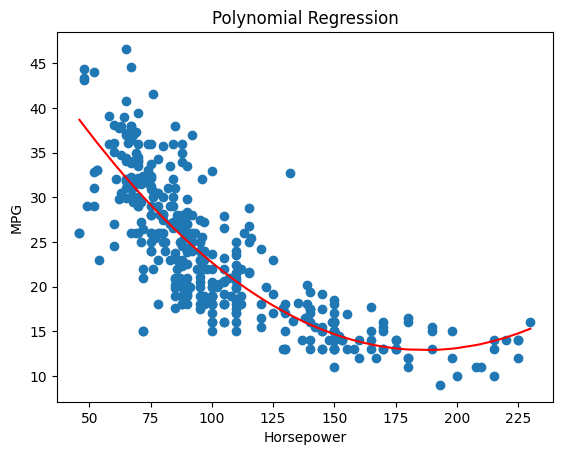

In [48]:
# Plotting

# Scatter plot of original data
plt.scatter(X, y)

# Sorting values for smooth curve
X_grid = X.sort_values(by='horsepower')

# Transform sorted X
X_grid_poly = poly.transform(X_grid)

# Predict curve values
y_curve = model.predict(X_grid_poly)

# Polynomial curve
plt.plot(X_grid, y_curve,color = 'red')

# Labels
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Polynomial Regression")

plt.show()